In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/marketinganalyticsCA")
!pwd

/content/drive/MyDrive/marketinganalyticsCA


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_walmart = pd.read_csv('Walmart.csv.xls')
df_walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df_walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df_walmart.shape

(6435, 8)

In [ ]:
df_walmart.duplicated().sum()

np.int64(0)

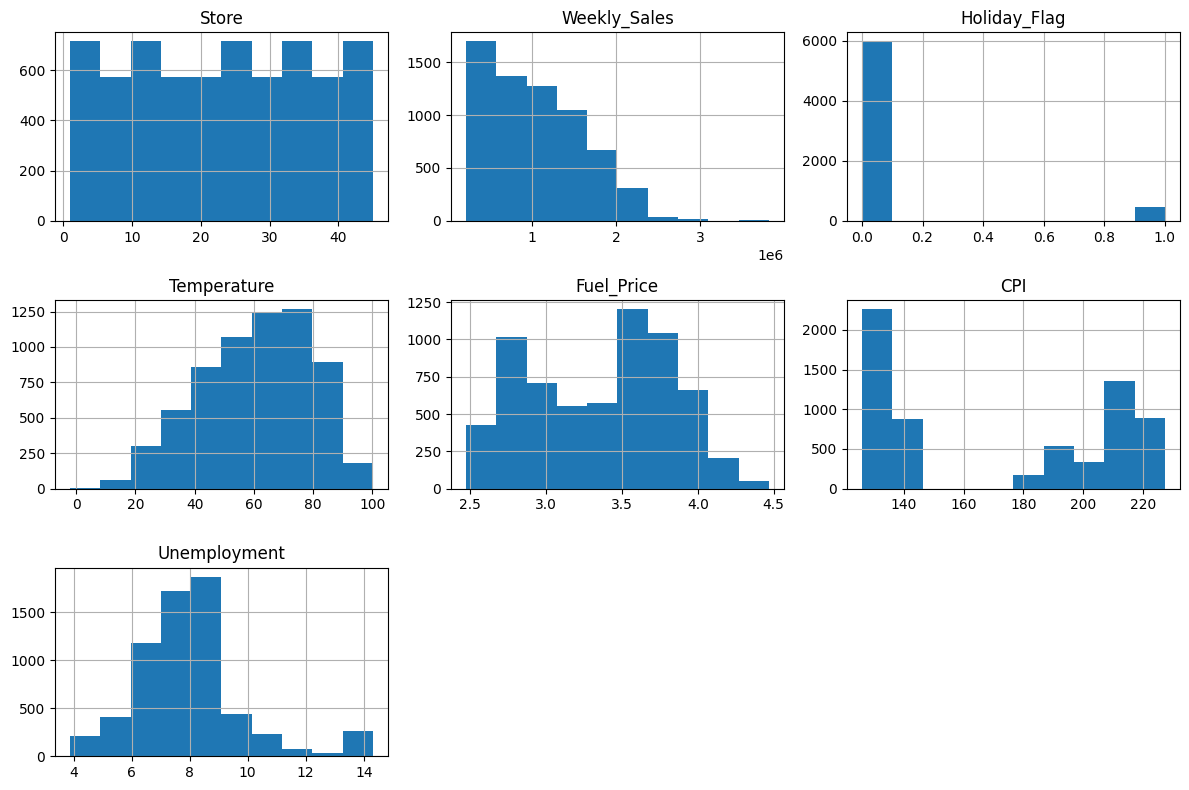

In [ ]:
import matplotlib.pyplot as plt

df_walmart.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
df_eda = df_walmart.copy()
df_tree = df_walmart.copy()
df_scaled = df_walmart.copy()

In [ ]:
df_eda['Date'] = pd.to_datetime(df_eda['Date'],dayfirst=True)

df_eda['Year'] = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Week'] = df_eda['Date'].dt.isocalendar().week

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 484.0 KB


#pre-processing RF, XG, LightGBM, ADAboost - just log tranformation

Log transformation to deal with skew

In [ ]:
df_tree['Weekly_Sales'] = np.log1p(df_tree['Weekly_Sales'])

In [ ]:
df_tree['Date'] = pd.to_datetime(df_tree['Date'],dayfirst=True)

df_tree['Month'] = df_tree['Date'].dt.month
df_tree['Week'] = df_tree['Date'].dt.isocalendar().week

In [ ]:
df_tree['Month_sin'] = np.sin(2 * np.pi * df_tree['Month'] / 12)
df_tree['Month_cos'] = np.cos(2 * np.pi * df_tree['Month'] / 12)

df_tree['Week_sin'] = np.sin(2 * np.pi * df_tree['Week'] / 52)
df_tree['Week_cos'] = np.cos(2 * np.pi * df_tree['Week'] / 52)

In [ ]:
df_tree.drop(['Month', 'Week', 'Date'], axis=1, inplace=True)

In [ ]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Month_sin     6435 non-null   float64
 8   Month_cos     6435 non-null   float64
 9   Week_sin      6435 non-null   Float64
 10  Week_cos      6435 non-null   Float64
dtypes: Float64(2), float64(7), int64(2)
memory usage: 565.7 KB


In [ ]:
df_tree['Store'] = df_tree['Store'].astype('category')
df_tree['Holiday_Flag'] = df_tree['Holiday_Flag'].astype('category')

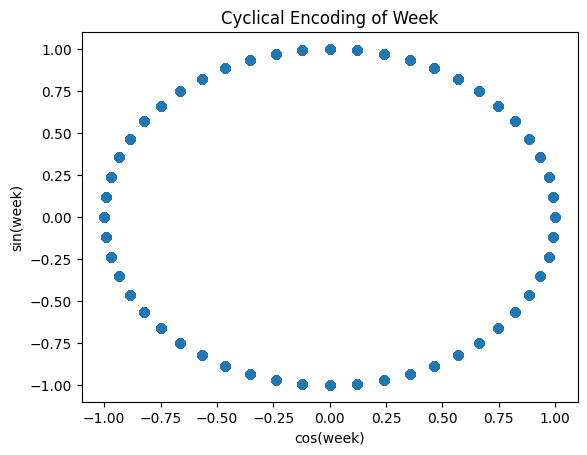

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_tree['Week_cos'], df_tree['Week_sin'])
plt.xlabel('cos(week)')
plt.ylabel('sin(week)')
plt.title('Cyclical Encoding of Week')
plt.show()

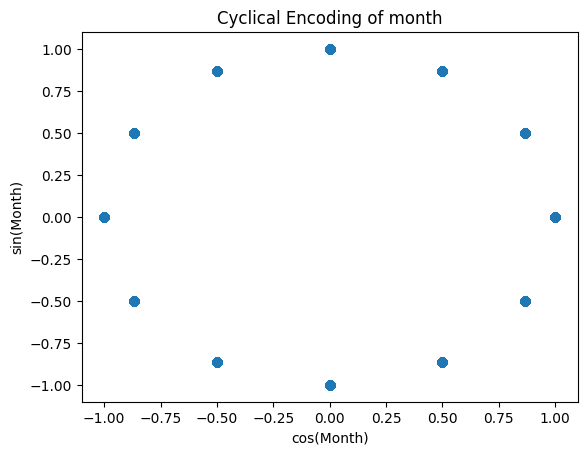

In [ ]:
plt.figure()
plt.scatter(df_tree['Month_cos'], df_tree['Month_sin'])
plt.xlabel('cos(Month)')
plt.ylabel('sin(Month)')
plt.title('Cyclical Encoding of month')
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_tree[['Store']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store'])
)

df_tree= pd.concat([df_tree.drop('Store', axis=1), encoded_df], axis=1)

# pre-processing MLR, SVM and NN - includes scaling and log transformation

all numerical features where scaled, weekly wales was log transformed then scaled to deal with skew

In [ ]:
df_scaled['Weekly_Sales'] = np.log1p(df_scaled['Weekly_Sales'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled['Weekly_Sales_scaled'] = scaler.fit_transform(df_scaled[['Weekly_Sales']])
df_scaled['Temperature_scaled'] = scaler.fit_transform(df_scaled[['Temperature']])
df_scaled['Fuel_Price_scaled'] = scaler.fit_transform(df_scaled[['Fuel_Price']])
df_scaled['CPI_scaled'] = scaler.fit_transform(df_scaled[['CPI']])
df_scaled['Unemployment_scaled'] = scaler.fit_transform(df_scaled[['Unemployment']])

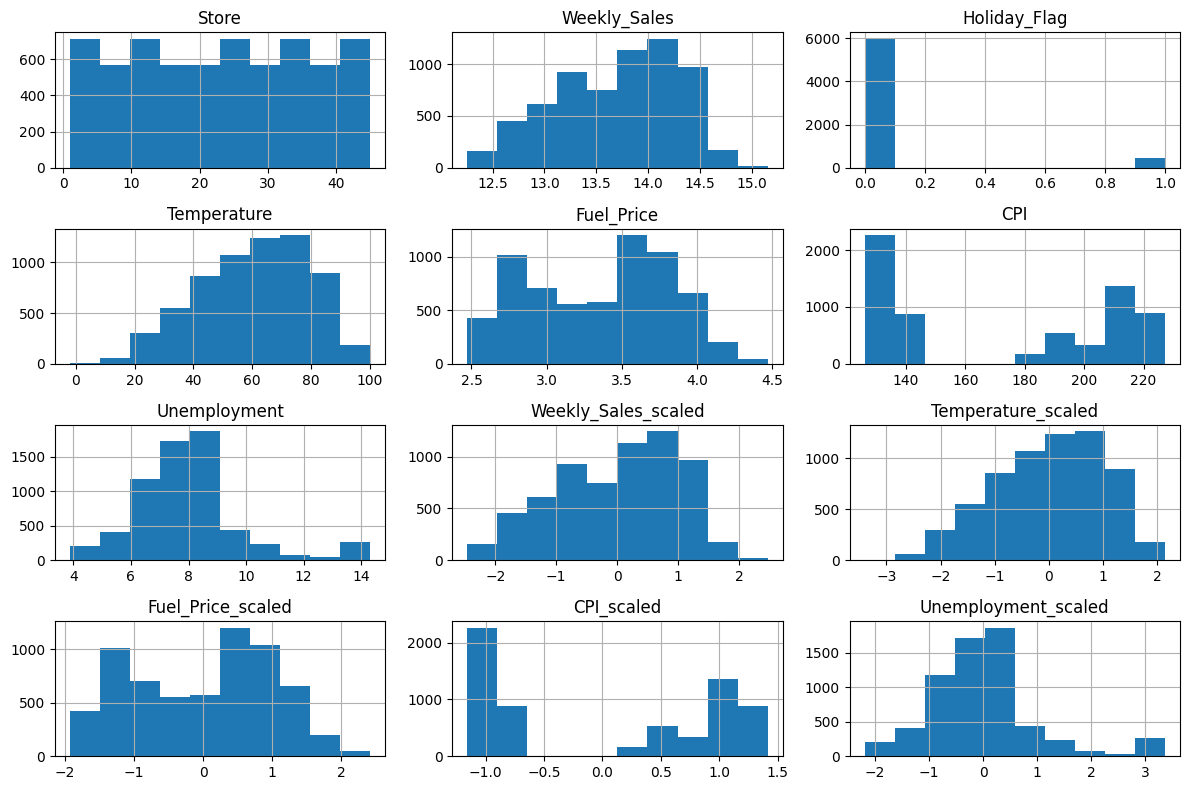

In [ ]:
df_scaled.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

date time processing

In [ ]:
df_scaled['Date'] = pd.to_datetime(df_scaled['Date'],dayfirst=True)

df_scaled['Month'] = df_scaled['Date'].dt.month
df_scaled['Week'] = df_scaled['Date'].dt.isocalendar().week

In [ ]:
df_scaled['Month_sin'] = np.sin(2 * np.pi * df_scaled['Month'] / 12)
df_scaled['Month_cos'] = np.cos(2 * np.pi * df_scaled['Month'] / 12)

df_scaled['Week_sin'] = np.sin(2 * np.pi * df_scaled['Week'] / 52)
df_scaled['Week_cos'] = np.cos(2 * np.pi * df_scaled['Week'] / 52)

In [ ]:
df_scaled.drop(['Date','Month','Week','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','Unemployment'], axis=1, inplace=True)

In [ ]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                6435 non-null   int64  
 1   CPI                  6435 non-null   float64
 2   Weekly_Sales_scaled  6435 non-null   float64
 3   Temperature_scaled   6435 non-null   float64
 4   Fuel_Price_scaled    6435 non-null   float64
 5   CPI_scaled           6435 non-null   float64
 6   Unemployment_scaled  6435 non-null   float64
 7   Month_sin            6435 non-null   float64
 8   Month_cos            6435 non-null   float64
 9   Week_sin             6435 non-null   Float64
 10  Week_cos             6435 non-null   Float64
dtypes: Float64(2), float64(8), int64(1)
memory usage: 565.7 KB


In [ ]:
df_scaled.head(1)

,Store,CPI,Weekly_Sales_scaled,Temperature_scaled,Fuel_Price_scaled,CPI_scaled,Unemployment_scaled,Month_sin,Month_cos,Week_sin,Week_cos
0,1,211.096358,1.037892,-0.995136,-1.7138,1.004175,0.056964,0.866025,0.5,0.568065,0.822984


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_scaled[['Store']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store'])
)

df_scaled= pd.concat([df_scaled.drop('Store', axis=1), encoded_df], axis=1)